# Data Exploration of hrv-covid19 Database

### Data Overview

The data comes from COVID-19 research in 2020 from the Welltory team. The Welltory app is an app which was used for users with a positive COVID-19 status to track their symptoms, heart rate variability, and other data. Heart rate variability was measured via any HR enabled device connectable with Bluetooth or a smartphone camera to measure optical blood volume changes. The data also includes integrated information from wearables, such as Apple Watch, Garmine, etc.

I chose to include the wearables dataset. The wearables dataset would be useful because it contains a variety of datapoints, whereas each specific csv only includes particular ones.

### Data loading

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns


# Load the wearables data
def load_csv(filepath, sep=',', encoding='utf-8', header=0, usecols=None, parse_dates=None):
  """
  Load the Web of Science CSV file into a pandas DataFrame.

  Parameters:
    filepath (str): path to the CSV file
    sep (str): delimiter used in the file (default ',')
    encoding (str): file encoding (default 'utf-8')
    header (int or None): row to use as column names (default 0)
    usecols (list or None): specific columns to load
    parse_dates (list or None): columns to parse as dates

  Returns:
    pd.DataFrame or None if loading fails
  """
  try:
      WoS_df = pd.read_csv(
        filepath,
        sep=sep,
        encoding=encoding,
        header=header,
        usecols=usecols,
        parse_dates=parse_dates
      )
      print(f"Loaded '{filepath}' successfully: {WoS_df.shape[0]} rows, {WoS_df.shape[1]} columns")
      return WoS_df
  except FileNotFoundError:
    print(f"Error: file not found at '{filepath}'")
  except pd.errors.EmptyDataError:
    print(f"Error: '{filepath}' is empty")
  except pd.errors.ParserError as e:
    print(f"Error parsing '{filepath}': {e}")
  except UnicodeDecodeError:
    print(f"Error: encoding issue with '{filepath}', try a different 'encoding' value")
  return None


wearables = load_csv("data/week4/wearables.csv")


Loaded 'data/week4/wearables.csv' successfully: 3098 rows, 18 columns


## Data Exploration

In [129]:
# Data Structure, wearables
print("Data Structure")
print("---------------")
print(f"Dimensions: {wearables.shape}")
print(f"Data Types:\n{wearables.dtypes}")
print(f"Missing Values:\n{wearables.isnull().sum()}")

Data Structure
---------------
Dimensions: (3098, 18)
Data Types:
user_code                           object
day                                 object
resting_pulse                      float64
pulse_average                      float64
pulse_min                          float64
pulse_max                          float64
average_spo2_value                 float64
body_temperature_avg               float64
stand_hours_total                  float64
steps_count                        float64
distance                           float64
steps_speed                        float64
total_number_of_flights_climbed    float64
active_calories_burned             float64
basal_calories_burned              float64
total_calories_burned              float64
average_headphone_exposure         float64
average_environment_exposure       float64
dtype: object
Missing Values:
user_code                             0
day                                   0
resting_pulse                      1583
pulse_aver

In [130]:
# Data Structure, blood pressure
print("Data Structure")
print("---------------")
print(f"Dimensions: {blood_pressure.shape}")
print(f"Data Types:\n{blood_pressure.dtypes}")
print(f"Missing Values:\n{blood_pressure.isnull().sum()}")

Data Structure
---------------
Dimensions: (721, 8)
Data Types:
user_code                    object
measurement_datetime         object
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object
Missing Values:
user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64


In [131]:
# Unique users
print("Unique Users")
print("---------------")
print(f"Unique Wearable Users:{wearables['user_code'].nunique()}")
print(f"Unique Wearable Users:{blood_pressure['user_code'].nunique()}")

Unique Users
---------------
Unique Wearable Users:79
Unique Wearable Users:28


In [132]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = wearables.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(wearables[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(wearables[numeric_columns].describe().loc[['std', 'min', 'max']])


Descriptive Statistics
----------------------
Central Tendency Measures:
      resting_pulse  pulse_average  pulse_min  pulse_max  average_spo2_value  \
mean      61.409241      78.084251  63.078506  99.456199               0.961   
50%       58.000000      76.000000  60.000000  96.000000               0.960   

      body_temperature_avg  stand_hours_total  steps_count     distance  \
mean             36.404615           8.986817  5342.067581  3494.690744   
50%              36.400000          10.000000  4477.500000  2687.000000   

      steps_speed  total_number_of_flights_climbed  active_calories_burned  \
mean    29.700409                        16.202429              750.721667   
50%     24.575000                         9.000000              180.000000   

      basal_calories_burned  total_calories_burned  \
mean            2258.165644             2549.04908   
50%             2271.000000             2353.00000   

      average_headphone_exposure  average_environment_exposur

In [133]:
# Making dates usable

wearables["day"] = pd.to_datetime(wearables["day"]).dt.date

In [134]:
# Observing trends for one wearable user
user_code = "01bad5a519"
obs = wearables.copy()
obs = obs.loc[obs["user_code"] == user_code]

# Data Structure
print("Data Structure")
print("---------------")
print(f"Dimensions: {obs.shape}")
print(f"Missing Values:\n{obs.isnull().sum()}")

# Date range
day_max = (obs["day"].max())
day_min = (obs["day"].min())
print("\nNumber of day tracked:")
print(f"User{user_code} was tracked for {(day_max - day_min).days} days")



Data Structure
---------------
Dimensions: (113, 18)
Missing Values:
user_code                            0
day                                  0
resting_pulse                       89
pulse_average                       75
pulse_min                           75
pulse_max                           75
average_spo2_value                 113
body_temperature_avg               113
stand_hours_total                  113
steps_count                          0
distance                           113
steps_speed                         32
total_number_of_flights_climbed    113
active_calories_burned             113
basal_calories_burned                0
total_calories_burned                0
average_headphone_exposure         113
average_environment_exposure       113
dtype: int64

Number of day tracked:
User01bad5a519 was tracked for 127 days


Given that the data is a covid dataset, my first question is how long each individual was tracked. Was it just over the course of their diagnosis or were they just sick at some point during the data tracking?

With this in mind, I'm going to create a new feature which counts the number of days since their first tracking. 

In [135]:
# Adding feature to wearables
wearables['first_date'] = wearables.groupby('user_code')['day'].transform('min')

# days since first recorded
wearables['days_since_first'] = (wearables['day'] - wearables['first_date'])

This was an important addition because it is time wise data which is meaningful in the context of an individual, so laying out the days since the original monitoring, and the number of days each user was tested is useful for later modeling which may stratify based on user rather than blind cuts between data.


Variable Relationships
----------------------
Correlation Matrix:
                                 resting_pulse  pulse_average  pulse_min  \
resting_pulse                         1.000000       0.338089   0.840694   
pulse_average                         0.338089       1.000000   0.315410   
pulse_min                             0.840694       0.315410   1.000000   
pulse_max                            -0.227967       0.663218  -0.328660   
average_spo2_value                    0.235886      -0.056980   0.127899   
body_temperature_avg                 -0.156849      -0.027397   0.027742   
stand_hours_total                    -0.078295       0.196996  -0.133089   
steps_count                          -0.122994       0.130591  -0.120087   
distance                             -0.159283       0.134463  -0.194156   
steps_speed                           0.125197      -0.010898   0.042564   
total_number_of_flights_climbed      -0.292782      -0.069213  -0.280784   
active_calories_burne

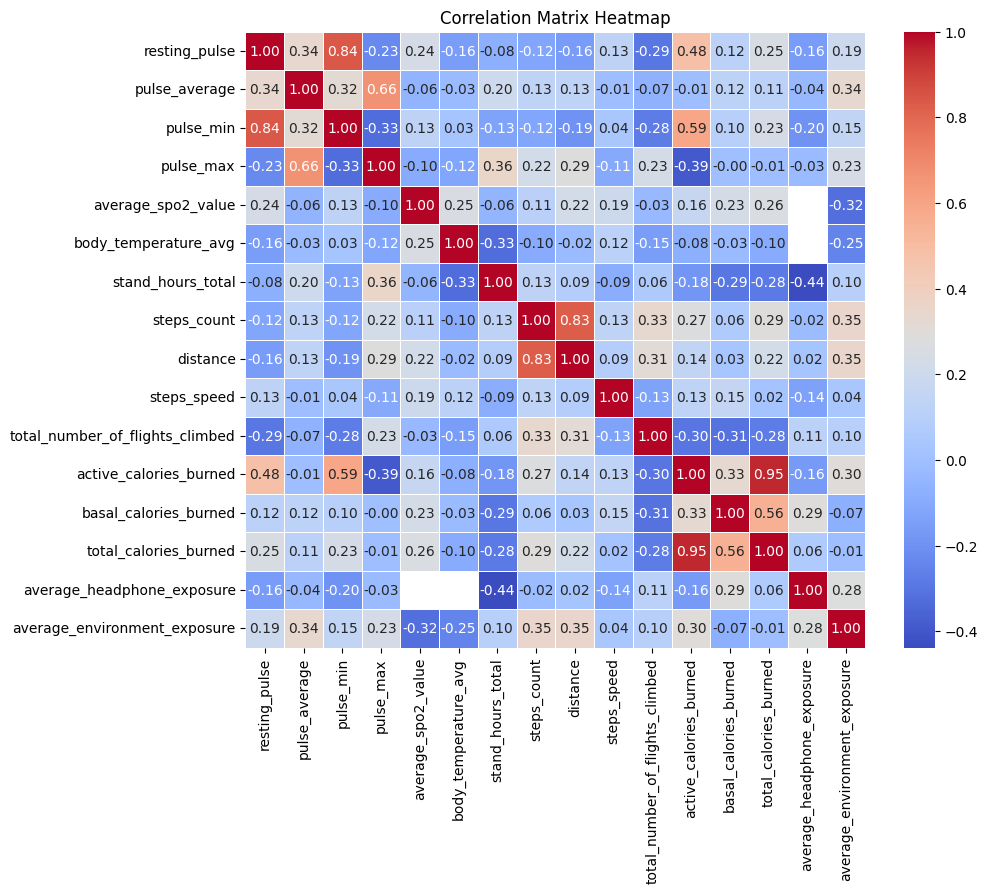

In [136]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix:")
correlation_matrix = wearables[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

This correlation matrix is helpful to look at the relative role of each feature. Future data analysis could remove certain features which weren't very relevant to making predictions on the data.

### DQA Analysis

Profiling: see descriptive statistics

Completeness: the missing values are alright in this dataset, because they're merely times when certain data wasn't recorded by the wearable. There were significant gaps, so filling in with an average wouldn't necessarilly be useful as there are so many gaps.

Accuracy: the data values make sense against what you would expect (ex. pulse around 77).

Consistency: (same as above)

Lineage and provenance: the data comes from wearables.

Automated testing: validation is baked into the new feature which analyzes how many days since testing first occurred for a user. This helps split data based on time series for an individual.